In [33]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 12.8 MB/s eta 0:00:08
   - -------------------------------------- 3.1/101.7 MB 9.8 MB/s eta 0:00:11
   - -------------------------------------- 3.9/101.7 MB 7.2 MB/s eta 0:00:14
   - -------------------------------------- 4.7/101.7 MB 5.9 MB/s eta 0:00:17
   -- ------------------------------------- 5.2/101.7 MB 5.4 MB/s eta 0:00:18
   -- ------------------------------------- 5.8/101.7 MB 4.9 MB/s eta 0:00:20
   -- ------------------------------------- 6.0/101.7 MB 4.3 MB/s eta 0:00:23
   -- ------------------------------------- 6.6/101.7 MB 3.8 MB/s eta 0:00:25
   -- ------------------------------------- 7.1/101.7 MB 3.7 MB/s eta 0:00:26
   -- ------------------------------------- 7.6/101.7 MB 3.6 MB/s eta 0:00:27
   --- ------------------------------------ 8.7/101.7 MB 3.6 MB/s eta 0:00:26
   --- ------------------------------------ 9.4/101.7 MB 3.7 MB/s eta 


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
df = pd.read_csv("../data/processed data/final_df.csv")
df.drop_duplicates(inplace = True)

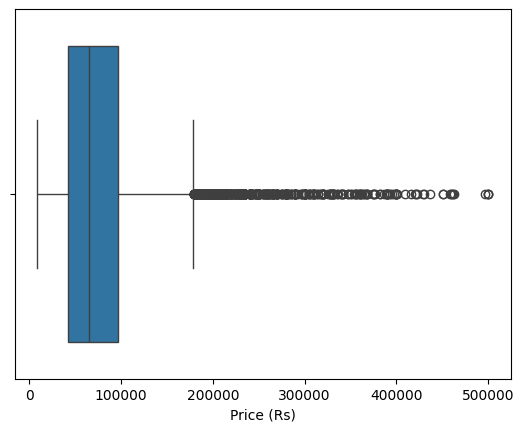

In [5]:
sns.boxplot(x = df["Price (Rs)"])
plt.show()

In [6]:
df["Price (Rs)"] = np.log(df["Price (Rs)"])

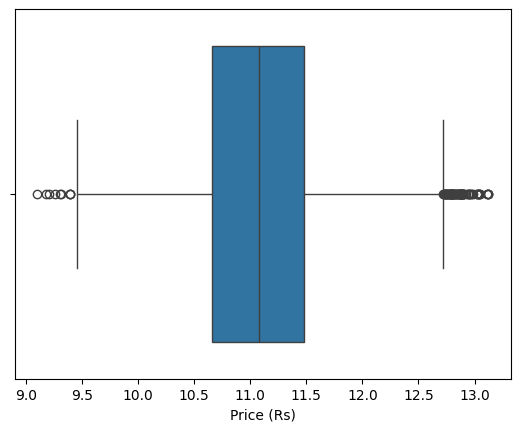

In [7]:
plt.clf()
sns.boxplot(x = df["Price (Rs)"])
plt.show()

In [8]:
df.dtypes

Unnamed: 0                 int64
Brand                      int64
Model                      int64
Series                     int64
Weight                   float64
Operating System           int64
Operating System Type      int64
Display Size             float64
Resolution_X               int64
Resolution_Y               int64
Pixel Density              int64
cpu_brand                  int64
cpu_model                  int64
Display Touchscreen        int64
Cache                      int64
Graphic Processor          int64
Capacity                   int64
SSD Capacity               int64
SSD Type                   int64
Graphics Memory            int64
HDD Capacity             float64
HDD Type                   int64
Battery Life             float64
market_status              int64
Price (Rs)               float64
dtype: object

In [9]:
df.isnull().sum()

Unnamed: 0               0
Brand                    0
Model                    0
Series                   0
Weight                   0
Operating System         0
Operating System Type    0
Display Size             0
Resolution_X             0
Resolution_Y             0
Pixel Density            0
cpu_brand                0
cpu_model                0
Display Touchscreen      0
Cache                    0
Graphic Processor        0
Capacity                 0
SSD Capacity             0
SSD Type                 0
Graphics Memory          0
HDD Capacity             0
HDD Type                 0
Battery Life             0
market_status            0
Price (Rs)               0
dtype: int64

In [10]:
df.shape

(8198, 25)

In [11]:
X = df.drop("Price (Rs)",axis = 1)
y = df["Price (Rs)"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [41]:
cat_cols = ['Brand', 'Model', 'Series', 'Weight', 'Operating System',
       'Operating System Type', 'Display Size', 'Resolution_X', 'Resolution_Y',
       'Pixel Density', 'Display Touchscreen', 'Cache',
       'Graphic Processor', 'Capacity', 'SSD Capacity', 'SSD Type',
       'Graphics Memory', 'HDD Capacity', 'HDD Type', 'Battery Life',
       'market_status']

In [42]:
print("X_train Columns", X_train.columns)
print("Cat_cols", cat_cols)

X_train Columns Index(['Unnamed: 0', 'Brand', 'Model', 'Series', 'Weight', 'Operating System',
       'Operating System Type', 'Display Size', 'Resolution_X', 'Resolution_Y',
       'Pixel Density', 'cpu_brand', 'cpu_model', 'Display Touchscreen',
       'Cache', 'Graphic Processor', 'Capacity', 'SSD Capacity', 'SSD Type',
       'Graphics Memory', 'HDD Capacity', 'HDD Type', 'Battery Life',
       'market_status'],
      dtype='str')
Cat_cols ['Brand', 'Model', 'Series', 'Weight', 'Operating System', 'Operating System Type', 'Display Size', 'Resolution_X', 'Resolution_Y', 'Pixel Density', 'Display Touchscreen', 'Cache', 'Graphic Processor', 'Capacity', 'SSD Capacity', 'SSD Type', 'Graphics Memory', 'HDD Capacity', 'HDD Type', 'Battery Life', 'market_status']


In [43]:
preprocessor = ColumnTransformer(
    transformers = [
        ("cat", OneHotEncoder(handle_unknown = "ignore" ),cat_cols)
    ],
    remainder = "passthrough"
)

In [44]:
pipeline = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("model", XGBRegressor())
])
pipeline.fit(X_train, y_train)
y_pred2 = pipeline.predict(X_test)

In [45]:
print("R2:" ,r2_score(y_test , y_pred2))

R2: 0.8984827067454879


In [51]:
param_grid = {
    "model__n_estimators" : [100,200],
    "model__max_depth" : [3,5,7],
    "model__learning_rate" : [0.05,0.1],
    "model__subsample" : [0.8, 1.0],
    "model__colsample_bytree" : [0.8, 1.0]
}

In [52]:
grid = GridSearchCV(
    pipeline, 
    param_grid, 
    cv = 3,
    scoring = "r2",
    n_jobs = -1
)
grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best Score: 0.8959628825427344


In [53]:
best_model = grid.best_estimator_

In [54]:
y_pred = best_model.predict(X_test)

In [55]:
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)
print("Real R2:", r2_score(y_test_actual, y_pred_actual))

Real R2: 0.8614945312044959


In [58]:
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE (%):", mape)

MAE: 12145.537023032586
RMSE: 22002.956078145453
MAPE (%): 14.036808547059069


In [60]:
import pickle
pickle.dump(best_model, open("laptop_price_model.pkl", "wb"))